# Heart Disease Prediction — Classification Model Evaluation

This notebook builds a simple classification model on the **Heart Disease Prediction** dataset and
walks through the key evaluation methods used for classifiers:

1. Precision / Recall
2. F1 Score
3. ROC-AUC
4. Confusion Matrix
5. Precision-Recall Curve
6. Threshold Tuning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,    
    recall_score,      
    f1_score,         
    roc_auc_score,         
    roc_curve,           
    confusion_matrix,      
    ConfusionMatrixDisplay,
    precision_recall_curve,
    classification_report 
)
plt.rcParams["figure.figsize"] = (6, 5)

In [2]:
df = pd.read_csv("Heart_Disease_Prediction.csv")
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
df.shape

(270, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

In [6]:
df["Heart Disease"].value_counts()

Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64

In [7]:
df["target"] = df["Heart Disease"].map({"Presence": 1, "Absence": 0})

# Drop the original text column now that we have a numeric version
df = df.drop(columns=["Heart Disease"])

df["target"].value_counts()

target
0    150
1    120
Name: count, dtype: int64

In [9]:
# X = all columns except the target -> these are the inputs the model learns from
X = df.drop(columns=["target"])

# y = the target column -> this is what the model tries to predict
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()

# fit_transform: learns the mean/std from the TRAINING data only, then scales it
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [16]:
model = LogisticRegression(max_iter=1000, random_state=42)

# .fit() trains the model using the scaled training features and their true labels
model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [23]:
y_pred = model.predict(X_test_scaled)


y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Peek at the first few predicted probabilities vs actual labels
pd.DataFrame({
    "actual": y_test.values[:10],
    "predicted_class": y_pred[:10],
    "predicted_probability": np.round(y_proba[:10], 3)
})

,actual,predicted_class,predicted_probability
0,1,1,0.676
1,1,1,0.993
2,0,0,0.118
3,1,1,0.998
4,0,0,0.028
5,0,1,0.983
6,0,0,0.033
7,0,0,0.091
8,1,1,0.588
9,1,1,0.975


In [24]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

print(cm)

[[32  6]
 [ 2 28]]


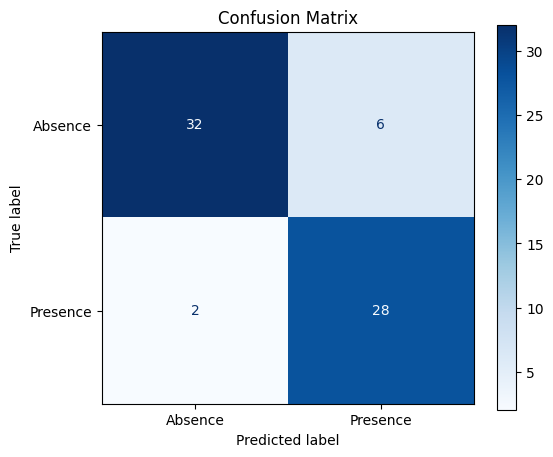

In [25]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Absence", "Presence"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [26]:
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

Precision: 0.824
Recall:    0.933
F1 Score:  0.875


In [27]:
print(classification_report(y_test, y_pred, target_names=["Absence", "Presence"]))

              precision    recall  f1-score   support

     Absence       0.94      0.84      0.89        38
    Presence       0.82      0.93      0.88        30

    accuracy                           0.88        68
   macro avg       0.88      0.89      0.88        68
weighted avg       0.89      0.88      0.88        68



## 4. ROC-AUC

The **ROC curve** plots the True Positive Rate (Recall) against the False Positive Rate
at every possible probability threshold. **AUC** (Area Under the Curve) summarizes this
into a single number between 0 and 1:

- 1.0 = perfect classifier
- 0.5 = no better than random guessing

In [28]:
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {auc_score:.3f}")

ROC-AUC Score: 0.920


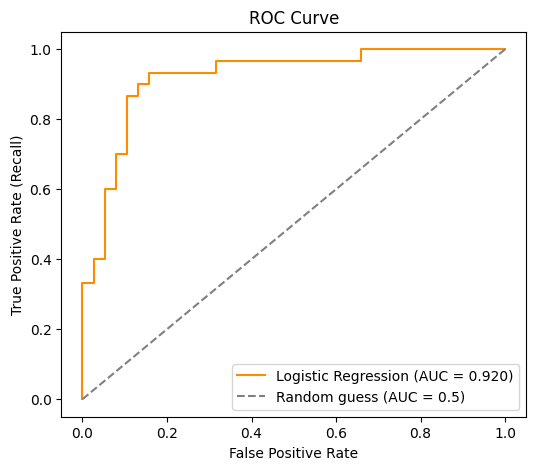

In [29]:

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

## 5. Precision-Recall Curve

This curve shows the trade-off between precision and recall as the classification
threshold changes. It's especially useful when the positive class is less common,
or when false negatives are costly (as in medical diagnosis).

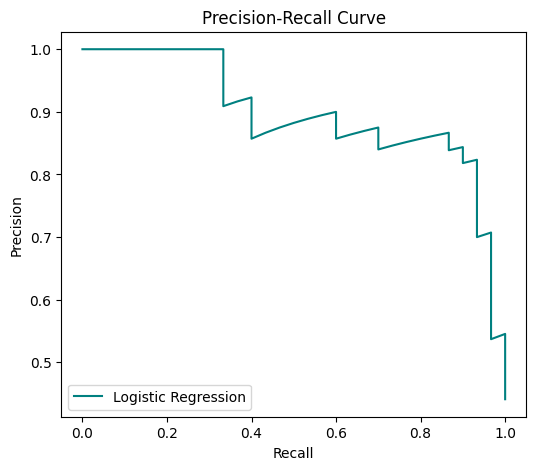

In [ ]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recalls, precisions, color="teal", label="Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()

## 6. Threshold Tuning

By default, `predict()` classifies a patient as "Presence" if the predicted probability
is **above 0.5**. But 0.5 isn't always the best cutoff — in a medical setting we may prefer
a LOWER threshold so we catch more true disease cases (higher recall), even if it means
a few more false alarms (lower precision).

Below, we test several thresholds and see how Precision, Recall, and F1 change.

In [31]:
# --- Try different probability thresholds and compare metrics ---

# Define a list of candidate thresholds to test, from strict to lenient
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []
for t in thresholds_to_test:
    # Convert probabilities into 0/1 predictions using threshold t instead of the default 0.5
    y_pred_t = (y_proba >= t).astype(int)

    # Recalculate precision, recall, and F1 at this new threshold
    p = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    r = recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)

    results.append({"threshold": t, "precision": round(p, 3), "recall": round(r, 3), "f1": round(f, 3)})

# Display the comparison as a table
threshold_df = pd.DataFrame(results)
threshold_df

,threshold,precision,recall,f1
0,0.3,0.737,0.933,0.824
1,0.4,0.800,0.933,0.862
2,0.5,0.824,0.933,0.875
3,0.6,0.844,0.900,0.871
4,0.7,0.852,0.767,0.807


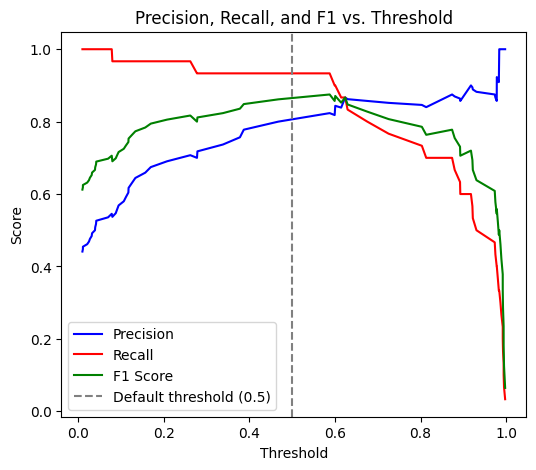

In [32]:
# --- Visualize how Precision, Recall, and F1 change across ALL thresholds ---

# We reuse the precision/recall values already computed for the PR curve.
# Note: pr_thresholds has one fewer element than precisions/recalls, so we trim the last value.
plt.plot(pr_thresholds, precisions[:-1], label="Precision", color="blue")
plt.plot(pr_thresholds, recalls[:-1], label="Recall", color="red")

# Compute F1 at every threshold manually: F1 = 2 * (P * R) / (P + R)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
plt.plot(pr_thresholds, f1_scores, label="F1 Score", color="green")

# Mark the default threshold (0.5) with a vertical line for reference
plt.axvline(x=0.5, linestyle="--", color="gray", label="Default threshold (0.5)")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs. Threshold")
plt.legend()
plt.show()

In [33]:
# --- Pick the threshold that gives the best F1 score ---

# argmax finds the index of the highest F1 score, then we look up the matching threshold
best_index = np.argmax(f1_scores)
best_threshold = pr_thresholds[best_index]

print(f"Best threshold for F1 score: {best_threshold:.3f}")
print(f"Precision at this threshold: {precisions[best_index]:.3f}")
print(f"Recall at this threshold:    {recalls[best_index]:.3f}")
print(f"F1 Score at this threshold:  {f1_scores[best_index]:.3f}")

Best threshold for F1 score: 0.588
Precision at this threshold: 0.824
Recall at this threshold:    0.933
F1 Score at this threshold:  0.875
